# Classic Forecasting: Exponential Smoothing

In Lessons 06 and 07, we took a detour into Machine Learning, transforming our temporal data into flat matrices so algorithms like XGBoost could process them.

Now, we return to **Classical Statistics**. While Machine Learning is incredibly powerful, it is computationally expensive and requires massive amounts of historical data. What if you need to generate a fast, reliable forecast for 10,000 different grocery store items overnight, and you only have 6 months of historical data?

Enter **Exponential Smoothing**. It is incredibly fast, natively understands time, and serves as the mathematical baseline for almost all enterprise forecasting.

Exponential Smoothing operates on a single, elegant philosophy: **Recent history is more important than ancient history.** If a simple Moving Average treats every day in a 30-day window with exactly equal weight, Exponential Smoothing applies a decaying weight. Yesterday is highly important, last week is somewhat important, and last year is barely a whisper.

Let's set up our Python environment to build these foundational models using `statsmodels`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Exponential Smoothing Environment Ready.")

✅ Exponential Smoothing Environment Ready.


# 1. Simple Exponential Smoothing (SES)

SES is used when your data has **No Trend** and **No Seasonality**. It only estimates the "Level" (the flat baseline) of the data.

### The Mathematical Engine: Alpha ($\alpha$)

The forecast for tomorrow ($\hat{y}_{t+1}$) is a weighted average of what actually happened today ($y_t$) and what we *predicted* would happen today ($\hat{y}_t$).


$$\hat{y}_{t+1} = \alpha y_t + (1 - \alpha) \hat{y}_t$$

* **$\alpha$ (Alpha)** is the Smoothing Parameter, constrained between $0$ and $1$.
* **If $\alpha = 1$**: The model has zero memory. Tomorrow's forecast is exactly equal to today's actual value (a "Naive Forecast"). It reacts violently to daily noise.
* **If $\alpha = 0$**: The model is completely stubborn. It ignores today's reality entirely and just predicts the historical global average forever.
* *Optimization*: The algorithm uses calculus to find the exact $\alpha$ that minimizes the Mean Squared Error (MSE).

# 2. Double Exponential Smoothing (Holt's Linear Trend)

SES has a fatal flaw: if a business is steadily growing (Trend), SES will always lag behind. It will constantly under-predict because it averages past, lower values.

In 1957, Charles Holt solved this by introducing a second mathematical equation to track the **Trend (Slope)**, controlled by a new parameter: **Beta ($\beta$)**.

1. **Level Equation ($\alpha$)**: Updates the baseline.
2. **Trend Equation ($\beta$)**: Updates the momentum/slope.

$$b_t = \beta (L_t - L_{t-1}) + (1 - \beta) b_{t-1}$$


3. **Forecast**: Combines the Level and the Trend to project upward or downward into the future.

# 3. Triple Exponential Smoothing (Holt-Winters)

In 1960, Peter Winters added the final piece: **Seasonality**.
If your data has a Level, a Trend, and a repeating cycle, we add a third equation controlled by **Gamma ($\gamma$)**.

This is the famous **Holt-Winters Model**. It is essentially an automated version of the Decomposition we did in Lesson 02. Just like Lesson 02, you must specify if the Trend and Seasonality are **Additive** (constant spikes) or **Multiplicative** (growing spikes).

# 4. Implementing the Three Models in Code

Let's simulate a complex time series (a growing airline business with heavy summer seasonal spikes) and unleash all three models on it. We will watch SES fail, Holt fail, and Holt-Winters succeed.

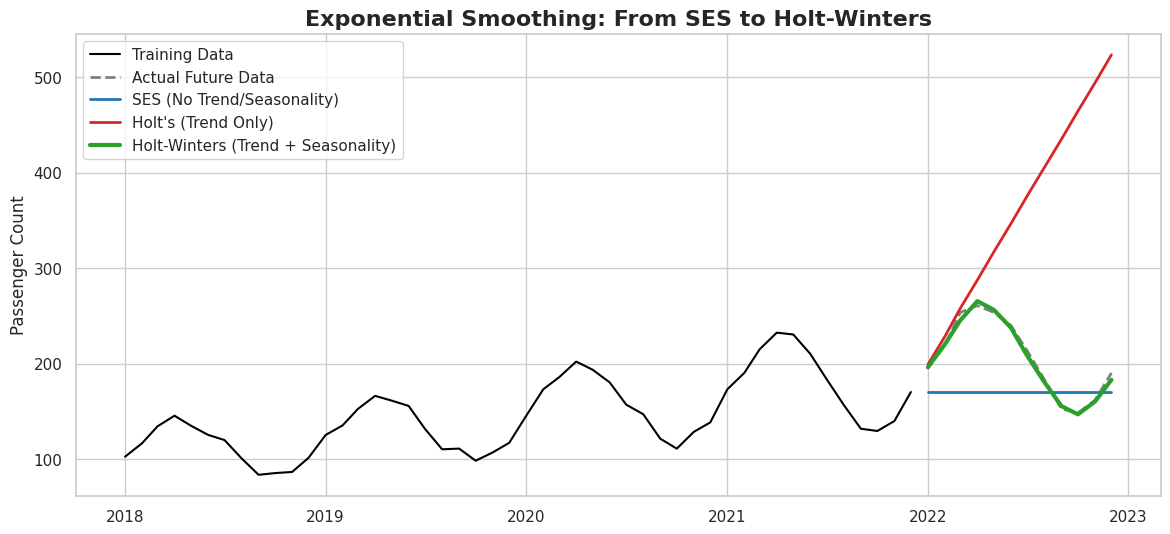

In [2]:
# 1. Simulate 5 years of Monthly Airline Passengers (Trend + Multiplicative Seasonality)
np.random.seed(42)
dates = pd.date_range(start='2018-01-01', periods=60, freq='MS')
t = np.arange(60)
trend = 100 + (t * 2) # Upward slope
seasonality = 1 + np.sin(t * (2 * np.pi / 12)) * 0.3 # 30% seasonal swing
y = trend * seasonality + np.random.normal(0, 5, 60)

df = pd.Series(y, index=dates)

# Split into Train (first 48 months) and Test (last 12 months)
train = df.iloc[:48]
test = df.iloc[48:]

# 2. Train Model 1: SES (Level Only)
# We let the algorithm optimize Alpha automatically
model_ses = SimpleExpSmoothing(train).fit()
pred_ses = model_ses.forecast(12)

# 3. Train Model 2: Holt (Level + Trend)
model_holt = Holt(train, exponential=False).fit()
pred_holt = model_holt.forecast(12)

# 4. Train Model 3: Holt-Winters (Level + Trend + Seasonality)
# We specify multiplicative seasonality with a 12-month period
model_hw = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit()
pred_hw = model_hw.forecast(12)

# 5. Matplotlib Visualization
plt.figure(figsize=(14, 6))

# Plot historical training data and actual future data
plt.plot(train.index, train, color='black', label='Training Data')
plt.plot(test.index, test, color='gray', linestyle='--', linewidth=2, label='Actual Future Data')

# Plot the Forecasts
plt.plot(test.index, pred_ses, color='#1f77b4', linewidth=2, label='SES (No Trend/Seasonality)')
plt.plot(test.index, pred_holt, color='#d62728', linewidth=2, label="Holt's (Trend Only)")
plt.plot(test.index, pred_hw, color='#2ca02c', linewidth=3, label='Holt-Winters (Trend + Seasonality)')

plt.title("Exponential Smoothing: From SES to Holt-Winters", fontsize=16, fontweight='bold')
plt.ylabel("Passenger Count")
plt.legend(loc='upper left')
plt.show()


*(Insight: Look at the forecasts projecting into the final year. The blue SES line is a catastrophic failure; it just flatlines at the last known average. The red Holt's line catches the upward trend but blasts straight through the summer peak and winter dip. The green Holt-Winters model perfectly traces the rhythmic, growing heartbeat of the actual data into the future!)*

---

## Real-World Use Case or Analogy:

Think of the Smoothing Parameters ($\alpha, \beta, \gamma$) like **The Steering Committee of a Corporation**:

* **Alpha (The Operations Manager)**: They look at daily sales. If a competitor runs a massive sale today and steals our customers ($y_t$ drops), a High Alpha manager panics, throws away the budget, and drastically lowers tomorrow's forecast. A Low Alpha manager stays calm and ignores the one-day anomaly.
* **Beta (The Strategic CFO)**: They look at the momentum. If the company has grown $5\%$ every quarter for a year, but this quarter it only grew $1\%$, a High Beta CFO aggressively downgrades the 5-year trend forecast. A Low Beta CFO stubbornly trusts the historical $5\%$ growth rate.
* **Gamma (The Marketing Director)**: They handle holidays. If last Black Friday had a massive spike, they store that memory and apply it to this year's Black Friday, adjusting the magnitude based on how strong the recent spikes were.

---